In [7]:
import glob, os
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread
from ipywidgets import interact, FloatSlider

# ── EDIT THESE ────────────────────────────────────────
INPUT_DIR  = '../data/images/D21'
OUTPUT_DIR = '../data/masks/D21'
# ──────────────────────────────────────────────────────

def load_by_id(folder):
    files = glob.glob(os.path.join(folder, '*.tif'))
    return {int(os.path.basename(f).split('_')[0]): f for f in files}

inputs  = load_by_id(INPUT_DIR)
outputs = load_by_id(OUTPUT_DIR)
matched = sorted(set(inputs) & set(outputs))
print(f'Matched IDs: {matched}')

Matched IDs: [31, 32, 33, 34, 35, 36, 37, 41, 42, 43, 44, 45, 76, 77, 81, 82, 86, 87, 121, 122, 126, 127, 131]


In [8]:
def normalize(img):
    img = img.astype(float)
    return (img - img.min()) / (img.max() - img.min() + 1e-8)

def show(image_id, alpha):
    img  = imread(inputs[image_id])                   # (H, W)  single channel
    mask = imread(outputs[image_id]) > 0   # shape: (H, W) | dtype: bool | 255=lumen interior (dark blobs) → True, 0=vessel walls (bright network) → False

    # Info
    h, w       = img.shape[:2]
    dtype      = img.dtype
    vmin, vmax = img.min(), img.max()
    n_vessel   = mask.sum()
    pct_vessel = 100 * n_vessel / mask.size
    fname_in   = os.path.basename(inputs[image_id])
    fname_out  = os.path.basename(outputs[image_id])

    fig, ax = plt.subplots(figsize=(14, 14))

    # Layer 1: raw grayscale image — no RGB conversion
    ax.imshow(normalize(img), cmap='gray')

    # Layer 2: mask as RGBA — alpha channel controls transparency directly
    mask_rgba       = np.zeros((*mask.shape, 4))      # (H, W, 4)
    mask_rgba[mask] = [1, 0, 0, alpha]                # red + transparency
    ax.imshow(mask_rgba)

    ax.set_title(
        f'Input:  {fname_in}\n'
        f'Output: {fname_out}\n'
        f'Mask:   red = vessel lumen (255 → True)  |  transparent = vessel walls / background (0 → False)\n'
        f'Resolution: {w} x {h} px  |  dtype: {dtype}  |  '
        f'Intensity range: [{vmin}, {vmax}]  |  '
        f'Vessel pixels: {n_vessel:,} ({pct_vessel:.1f}%)  |  '
        f'Mask alpha: {alpha:.2f}',
        fontsize=11, loc='left'
    )
    ax.axis('off')
    plt.tight_layout()
    plt.show()

interact(
    show,
    image_id = matched,
    alpha    = FloatSlider(value=0.4, min=0.0, max=1.0, step=0.05, 
                           description='Mask alpha', continuous_update=False)
);

interactive(children=(Dropdown(description='image_id', options=(31, 32, 33, 34, 35, 36, 37, 41, 42, 43, 44, 45…

unique values: [  0 255]
dtype: uint8
shape: (1300, 15800)


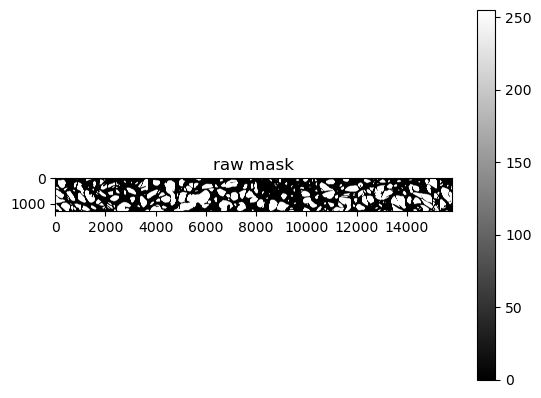

In [3]:
raw_mask = imread(outputs[matched[0]])
print('unique values:', np.unique(raw_mask))
print('dtype:', raw_mask.dtype)
print('shape:', raw_mask.shape)

# Also visually inspect mask alone
plt.imshow(raw_mask, cmap='gray')
plt.colorbar()
plt.title('raw mask')
plt.show()